# 🚂 Analisis Sentimen Ulasan KAI Access (Google Play Store)
 4 Skema Pelatihan Deep Learning
 1. RNN + RNN (SimpleRNN) + Embedding Layer
 2. BiLTSM + FastText
 3. GRU + FastText
 4. IndoBERT +


---
## 📦 0. Instalasi Library

In [2]:
!pip install tensorflow keras
!pip install transformers
!pip install gensim
!pip install nltk scikit-learn pandas numpy matplotlib seaborn
!pip install Sastrawi

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 73.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 9.7 MB/s eta 0:00:00


---
## 🏷️ 1. Pelabelan Data (Berdasarkan Rating)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('kai_access_raw.csv')

def label_sentimen(rating):
    if rating <= 2:
        return 'Negatif'
    elif rating == 3:
        return 'Netral'
    else:
        return 'Positif'

df['label'] = df['rating'].apply(label_sentimen)
df['label_id'] = df['label'].map({'Negatif': 0, 'Netral': 1, 'Positif': 2})

print('Distribusi Label:')
print(df['label'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=df, palette='Set2', order=['Negatif','Netral','Positif'])
plt.title('Distribusi Kelas Sentimen KAI Access')
plt.xlabel('Kelas')
plt.ylabel('Jumlah')
plt.tight_layout()
plt.savefig('distribusi_kelas.png', dpi=150)
plt.show()

df.to_csv('kai_access_labeled.csv', index=False)
print('\nData berlabel tersimpan ke kai_access_labeled.csv')

---
## 🧹 2. Preprocessing Teks

In [ ]:
import re
import nltk
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

nltk.download('punkt')

factory_stem = StemmerFactory()
stemmer = factory_stem.create_stemmer()

factory_stop = StopWordRemoverFactory()
stopword = factory_stop.create_stop_word_remover()

def preprocess(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = stopword.remove(text)
    text = stemmer.stem(text)
    return text

df = pd.read_csv('kai_access_labeled.csv')
df['ulasan_bersih'] = df['ulasan'].apply(preprocess)

df = df[df['ulasan_bersih'].str.strip() != '']
df = df.dropna(subset=['ulasan_bersih'])
df.reset_index(drop=True, inplace=True)

print(f'Jumlah data setelah preprocessing: {len(df)}')
print(df[['ulasan', 'ulasan_bersih', 'label']].head())

df.to_csv('kai_access_clean.csv', index=False)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Jumlah data setelah preprocessing: 11567
                                              ulasan  \
0  plissss PERBAIKI APLIKASI KAI ACCES LEMOT SULI...   
1  Kereta Kuala Stabas rute Baturaja–Tanjung Kara...   
2  Kereta Kuala Stabas rute Baturaja–Tanjung Kara...   
3  Jadwal KRL gajelas tolong perbaiki sering bang...   
4                                              error   

                                       ulasan_bersih    label  
0  plissss baik aplikasi kai acces lot sulit jadi...  Negatif  
1  kereta kuala stabas rute baturaja tanjung kara...  Negatif  
2  kereta kuala stabas rute baturaja tanjung kara...  Negatif  
3  jadwal krl gajelas baik sering banget jadwal g...  Negatif  
4                                              error  Negatif  


---
## ⚖️ 3. Class Weight


Hitung class weight

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
import numpy as np

df = pd.read_csv('kai_access_clean (1).csv')

df_pos = df[df['label'] == 'Positif']
df_neg = df[df['label'] == 'Negatif']
df_neu = df[df['label'] == 'Netral']

print("Sebelum oversample:")
print(df['label'].value_counts())

target_neu = 3000
if len(df_neu) < target_neu:
    df_neu_upsampled = resample(df_neu, replace=True, n_samples=target_neu, random_state=42)
else:
    df_neu_upsampled = df_neu

df_balanced = pd.concat([df_pos, df_neg, df_neu_upsampled])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nSetelah oversample Netral:")
print(df_balanced['label'].value_counts())
print(f"Total data: {len(df_balanced)}")

df_balanced.to_csv('kai_access_oversampled(1).csv', index=False)

from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_balanced = le.fit_transform(df_balanced['label'])

class_weights = compute_class_weight('balanced', classes=np.unique(y_balanced), y=y_balanced)
weight_dict = {i: w for i, w in enumerate(class_weights)}
print("\nClass weight setelah oversample:")
print(f"Negatif (0): {weight_dict[0]:.3f}")
print(f"Netral  (1): {weight_dict[1]:.3f}")
print(f"Positif (2): {weight_dict[2]:.3f}")

Sebelum oversample:
label
Positif    6124
Negatif    4723
Netral      720
Name: count, dtype: int64

Setelah oversample Netral:
label
Positif    6124
Negatif    4723
Netral     3000
Name: count, dtype: int64
Total data: 13847

Class weight setelah oversample:
Negatif (0): 0.977
Netral  (1): 1.539
Positif (2): 0.754


In [ ]:
"""
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
import numpy as np

df = pd.read_csv('kai_access_clean.csv')
label_encoder = LabelEncoder()
y_all = label_encoder.fit_transform(df['label'])  # 0=Negatif, 1=Netral, 2=Positif

class_weights = compute_class_weight('balanced', classes=np.unique(y_all), y=y_all)
weight_dict = {i: w for i, w in enumerate(class_weights)}
print("Class weight:")
print(f"Negatif (0): {weight_dict[0]:.3f}")
print(f"Netral  (1): {weight_dict[1]:.3f}")
print(f"Positif (2): {weight_dict[2]:.3f}")

# Simpan label encoder global untuk inference
import pickle
with open('label_encoder_global.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

"""

Class weight:
Negatif (0): 0.816
Netral  (1): 5.355
Positif (2): 0.630


---
# 🧠 SKEMA 1: RNN (SimpleRNN) + Embedding Layer — Pembagian 80/20

Class weight: {0: np.float64(0.9773248632433387), 1: np.float64(1.5384722222222222), 2: np.float64(0.7536912295026196)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step - accuracy: 0.5511 - loss: 0.9501 - val_accuracy: 0.7170 - val_loss: 0.6681
Epoch 2/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.8092 - loss: 0.5228 - val_accuracy: 0.8177 - val_loss: 0.4774
Epoch 3/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.8951 - loss: 0.2953 - val_accuracy: 0.8188 - val_loss: 0.5160
Epoch 4/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9291 - loss: 0.2076 - val_accuracy: 0.8242 - val_loss: 0.5786
Epoch 5/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9438 - loss: 0.1711 - val_accuracy: 0.8397 - val_loss: 0.5745
Epoch 6/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9120 - loss: 0.2692 - val_accuracy: 0.7978 - val_loss: 0.6668
Epoch 7/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9306 - loss: 0.2039 - val_accuracy: 0.8321 - val_loss: 0.6131
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

=== RNN + Class Weight ===
Akurasi Train: 96.52%
Akuras

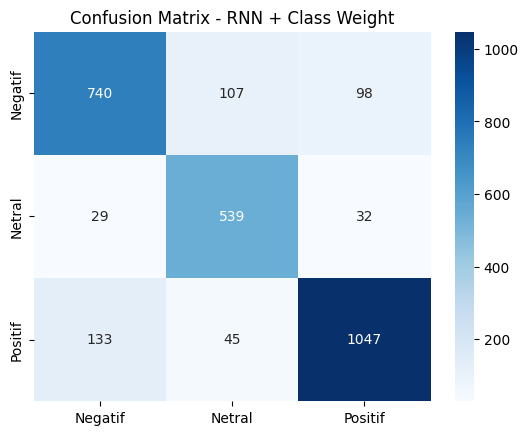

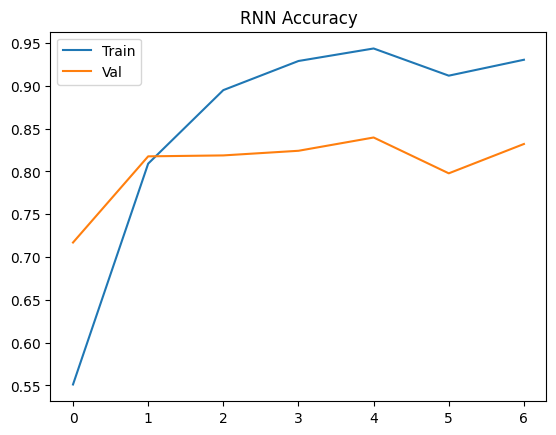

In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns

# Load data oversampled
df = pd.read_csv('kai_access_oversampled.csv')
le1 = LabelEncoder()
y1 = le1.fit_transform(df['label'])

MAX_WORDS = 15000
MAX_LEN = 100

tokenizer_rnn = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer_rnn.fit_on_texts(df['ulasan_bersih'])
X = pad_sequences(tokenizer_rnn.texts_to_sequences(df['ulasan_bersih']), maxlen=MAX_LEN)

X_train, X_test, y_train, y_test = train_test_split(X, y1, test_size=0.2, random_state=42, stratify=y1)
y_train_cat = tf.keras.utils.to_categorical(y_train, 3)
y_test_cat = tf.keras.utils.to_categorical(y_test, 3)

# Class weight dari data train
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
weight_dict = {i: w for i, w in enumerate(class_weights)}
print("Class weight:", weight_dict)

# KEMBALI ke arsitektur SEDERHANA yang terbukti berhasil
model_rnn = Sequential([
    Embedding(MAX_WORDS, 128, input_length=MAX_LEN),
    SimpleRNN(128, return_sequences=True),
    Dropout(0.3),
    SimpleRNN(64),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])

model_rnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_rnn.summary()

# Early stopping yang TEPAT: monitor val_accuracy, patience=2 atau 3
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=2,                     # lebih agresif (2 epoch)
    restore_best_weights=True,
    mode='max'
)

history_rnn = model_rnn.fit(
    X_train, y_train_cat,
    epochs=30,
    batch_size=64,
    validation_data=(X_test, y_test_cat),
    callbacks=[early_stop],
    class_weight=weight_dict,
    verbose=1
)

# Evaluasi
def eval_model(model, X_train, y_train, X_test, y_test, le, title):
    train_acc = model.evaluate(X_train, tf.keras.utils.to_categorical(y_train, 3), verbose=0)[1]
    test_acc = model.evaluate(X_test, tf.keras.utils.to_categorical(y_test, 3), verbose=0)[1]
    y_pred = np.argmax(model.predict(X_test), axis=1)
    print(f'\n=== {title} ===')
    print(f'Akurasi Train: {train_acc*100:.2f}%')
    print(f'Akurasi Test : {test_acc*100:.2f}%')
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Confusion Matrix - {title}')
    plt.show()
    return train_acc, test_acc

acc1_train, acc1_test = eval_model(model_rnn, X_train, y_train, X_test, y_test, le1, 'RNN + Class Weight')

plt.plot(history_rnn.history['accuracy'], label='Train')
plt.plot(history_rnn.history['val_accuracy'], label='Val')
plt.title('RNN Accuracy')
plt.legend()
plt.show()

---
# 🧠 SKEMA 2: BiLSTM + FastText/Word2Vec Embedding — Pembagian 80/20

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │     1,920,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,920,000 (7.32 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,920,000 (7.32 MB)

Epoch 1/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.6550 - loss: 0.7891 - val_accuracy: 0.7040 - val_loss: 0.6952
Epoch 2/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.7136 - loss: 0.7082 - val_accuracy: 0.7094 - val_loss: 0.6591
Epoch 3/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.7323 - loss: 0.6735 - val_accuracy: 0.7444 - val_loss: 0.6273
Epoch 4/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.7512 - loss: 0.6425 - val_accuracy: 0.7585 - val_loss: 0.5934
Epoch 5/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.7675 - loss: 0.6084 - val_accuracy: 0.7527 - val_loss: 0.6078
Epoch 6/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.7894 - loss: 0.5586 - val_accuracy: 0.7596 - val_loss: 0.5998
Epoch 7/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.8090 - loss: 0.5122 - val_accuracy: 0.7931 - val_loss: 0.5402
Epoch 8/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.8208 - loss: 0.4837 - val_acc

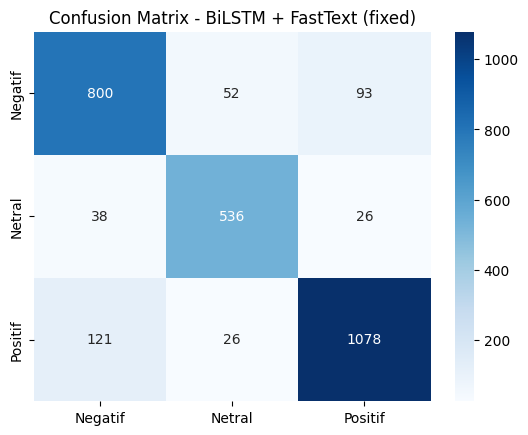

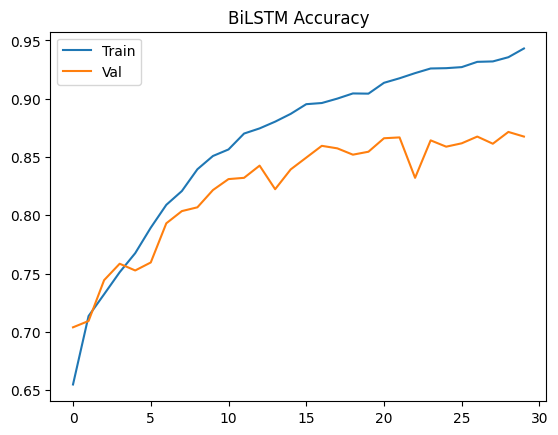

In [5]:
import gensim
from gensim.models import FastText
from tensorflow.keras.layers import Bidirectional, LSTM

df = pd.read_csv('kai_access_oversampled.csv')
le2 = LabelEncoder()
y2 = le2.fit_transform(df['label'])

# Latih FastText dari data bersih
sentences = [text.split() for text in df['ulasan_bersih']]
ft_model = FastText(sentences=sentences, vector_size=128, window=5, min_count=2, epochs=10, sg=1)
ft_model.save('fasttext_kai.model')

MAX_WORDS2 = 15000
MAX_LEN2 = 100
EMBED_DIM = 128

tokenizer_bilstm = Tokenizer(num_words=MAX_WORDS2, oov_token='<OOV>')
tokenizer_bilstm.fit_on_texts(df['ulasan_bersih'])
X2 = pad_sequences(tokenizer_bilstm.texts_to_sequences(df['ulasan_bersih']), maxlen=MAX_LEN2)

embedding_matrix = np.zeros((MAX_WORDS2, EMBED_DIM))
for word, idx in tokenizer_bilstm.word_index.items():
    if idx < MAX_WORDS2 and word in ft_model.wv:
        embedding_matrix[idx] = ft_model.wv[word]

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42, stratify=y2)
y2_train_cat = tf.keras.utils.to_categorical(y2_train, 3)
y2_test_cat = tf.keras.utils.to_categorical(y2_test, 3)

model_bilstm = Sequential([
    Embedding(MAX_WORDS2, EMBED_DIM, weights=[embedding_matrix], input_length=MAX_LEN2, trainable=False),
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(64)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])
model_bilstm.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_bilstm.summary()

early_stop2 = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
history_bilstm = model_bilstm.fit(X2_train, y2_train_cat, epochs=30, batch_size=64,
                                  validation_data=(X2_test, y2_test_cat),
                                  callbacks=[early_stop2],
                                  class_weight=weight_dict,
                                  verbose=1)

acc2_train, acc2_test = eval_model(model_bilstm, X2_train, y2_train, X2_test, y2_test, le2, 'BiLSTM + FastText (fixed)')

plt.plot(history_bilstm.history['accuracy'], label='Train')
plt.plot(history_bilstm.history['val_accuracy'], label='Val')
plt.title('BiLSTM Accuracy')
plt.legend()
plt.show()

---
# 🧠 SKEMA 3: GRU + FastText (Fine-tuned Embedding) — Split 80/20

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     1,920,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,920,000 (7.32 MB)

 Trainable params: 1,920,000 (7.32 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 75s 403ms/step - accuracy: 0.6346 - loss: 0.8099 - val_accuracy: 0.7166 - val_loss: 0.6582
Epoch 2/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 66s 314ms/step - accuracy: 0.7199 - loss: 0.6882 - val_accuracy: 0.7542 - val_loss: 0.6095
Epoch 3/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 61s 350ms/step - accuracy: 0.7786 - loss: 0.5904 - val_accuracy: 0.7903 - val_loss: 0.5555
Epoch 4/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 55s 318ms/step - accuracy: 0.8198 - loss: 0.4971 - val_accuracy: 0.8072 - val_loss: 0.5032
Epoch 5/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 82s 316ms/step - accuracy: 0.8491 - loss: 0.4210 - val_accuracy: 0.8267 - val_loss: 0.4801
Epoch 6/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 56s 318ms/step - accuracy: 0.8727 - loss: 0.3567 - val_accuracy: 0.8318 - val_loss: 0.4490
Epoch 7/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 55s 315ms/step - accuracy: 0.8963 - loss: 0.3057 - val_accuracy: 0.8401 - val_loss: 0.4560
Epoch 8/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 55s 318ms/step - accuracy: 0.9068 - loss: 0

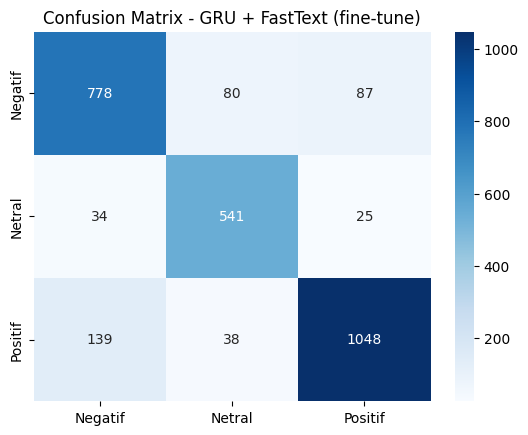

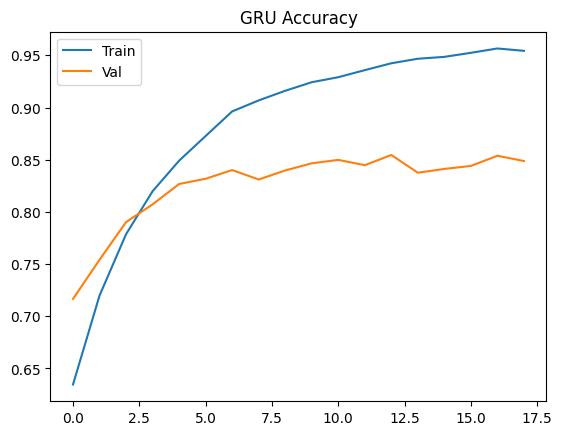

In [6]:
from tensorflow.keras.layers import GRU

df = pd.read_csv('kai_access_oversampled.csv')
le3 = LabelEncoder()
y3 = le3.fit_transform(df['label'])

# Load FastText yang sudah dilatih (skema 2)
ft_model3 = FastText.load('fasttext_kai.model')

MAX_WORDS3 = 15000
MAX_LEN3 = 100
EMBED_DIM3 = 128

tokenizer_gru = Tokenizer(num_words=MAX_WORDS3, oov_token='<OOV>')
tokenizer_gru.fit_on_texts(df['ulasan_bersih'])
X3 = pad_sequences(tokenizer_gru.texts_to_sequences(df['ulasan_bersih']), maxlen=MAX_LEN3)

embedding_matrix3 = np.zeros((MAX_WORDS3, EMBED_DIM3))
for word, idx in tokenizer_gru.word_index.items():
    if idx < MAX_WORDS3 and word in ft_model3.wv:
        embedding_matrix3[idx] = ft_model3.wv[word]

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42, stratify=y3)
y3_train_cat = tf.keras.utils.to_categorical(y3_train, 3)
y3_test_cat = tf.keras.utils.to_categorical(y3_test, 3)

model_gru = Sequential([
    Embedding(MAX_WORDS3, EMBED_DIM3, weights=[embedding_matrix3], input_length=MAX_LEN3, trainable=True),
    GRU(128, dropout=0.2, recurrent_dropout=0.2),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])
model_gru.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_gru.summary()

early_stop3 = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
history_gru = model_gru.fit(X3_train, y3_train_cat, epochs=30, batch_size=64,
                            validation_data=(X3_test, y3_test_cat),
                            callbacks=[early_stop3],
                            class_weight=weight_dict,
                            verbose=1)

acc3_train, acc3_test = eval_model(model_gru, X3_train, y3_train, X3_test, y3_test, le3, 'GRU + FastText (fine-tune)')

plt.plot(history_gru.history['accuracy'], label='Train')
plt.plot(history_gru.history['val_accuracy'], label='Val')
plt.title('GRU Accuracy')
plt.legend()
plt.show()

---
# 🧠 SKEMA 4 : IndoBERT — Split 80/20

Device: cuda
Total data: 11933
label
Positif    6482
Negatif    4728
Netral      723
Name: count, dtype: int64

Distribusi setelah balancing:
label
Positif    5000
Negatif    4728
Netral     4000
Name: count, dtype: int64

Train: 10982 | Test: 2746


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



  TRAINING IndoBERT — Skema 4
Epoch 1/5 | Train Loss: 0.2840 Acc: 69.73% | Val Loss: 0.2205 Acc: 79.61% ✅ saved
Epoch 2/5 | Train Loss: 0.1528 Acc: 86.24% | Val Loss: 0.1414 Acc: 87.36% ✅ saved
Epoch 3/5 | Train Loss: 0.0716 Acc: 93.32% | Val Loss: 0.1273 Acc: 89.33% ✅ saved
Epoch 4/5 | Train Loss: 0.0415 Acc: 96.12% | Val Loss: 0.1599 Acc: 88.71%
Epoch 5/5 | Train Loss: 0.0276 Acc: 97.48% | Val Loss: 0.1759 Acc: 88.93%

Best Val Accuracy: 89.33%
Target 93%: ❌ Belum 93%

  EVALUASI FINAL — IndoBERT Skema 4
  Akurasi Test  : 89.33%
  Target 93%    : ❌ Belum 93%

              precision    recall  f1-score   support

     Negatif       0.90      0.86      0.88       946
      Netral       0.86      0.93      0.89       800
     Positif       0.92      0.89      0.90      1000

    accuracy                           0.89      2746
   macro avg       0.89      0.90      0.89      2746
weighted avg       0.89      0.89      0.89      2746



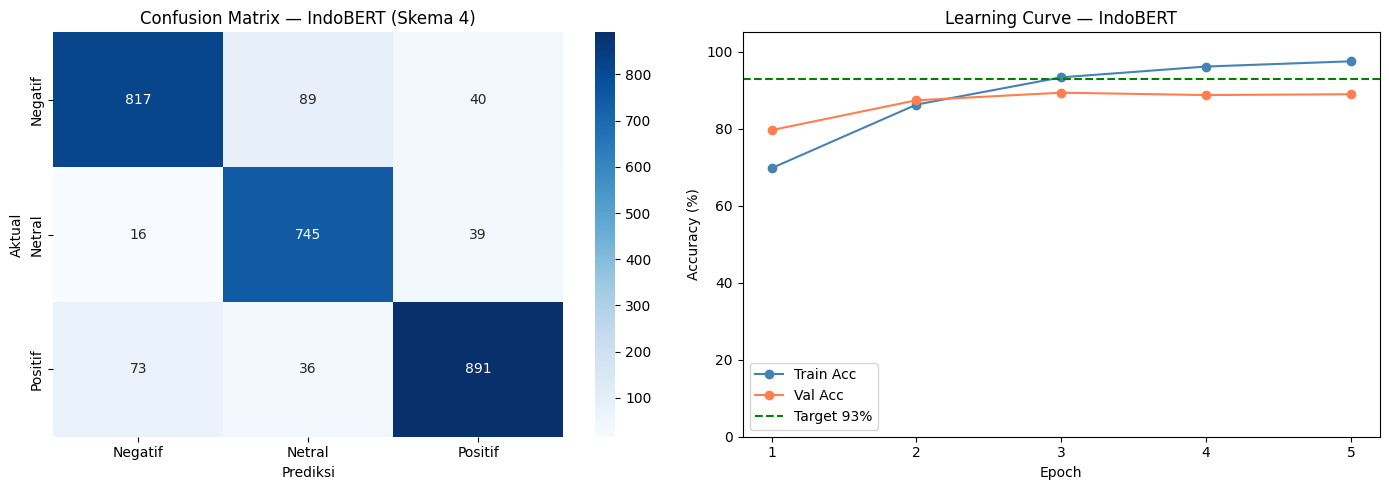


=== INFERENCE — Skema 4 IndoBERT ===
Input    : Aplikasinya sangat bagus dan mudah digunakan, pembelian tiket jadi gampang!
Prediksi : Positif (95.7%)
Prob     : Negatif=3.3% Netral=1.1% Positif=95.7%
-----------------------------------------------------------------
Input    : Biasa saja sih, tidak ada yang spesial dari aplikasi ini
Prediksi : Negatif (53.9%)
Prob     : Negatif=53.9% Netral=0.5% Positif=45.6%
-----------------------------------------------------------------
Input    : Aplikasi sering error dan tiket tidak muncul setelah bayar, sangat mengecewakan!
Prediksi : Negatif (89.8%)
Prob     : Negatif=89.8% Netral=1.2% Positif=9.1%
-----------------------------------------------------------------
Input    : Lumayan oke lah buat beli tiket, tapi kadang agak lemot
Prediksi : Positif (60.7%)
Prob     : Negatif=6.2% Netral=33.1% Positif=60.7%
-----------------------------------------------------------------
Input    : Gak bisa login udah 3 hari, cs nya juga ga respon sama sekali
P

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ IndoBERT model, tokenizer, dan label encoder berhasil disimpan!
   Folder: indobert_kai_final/
   Label encoder: le_indobert.pkl


In [7]:
!pip install transformers torch scikit-learn pandas numpy
!pip install Sastrawi imbalanced-learn seaborn matplotlib
!pip install accelerate

import os
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    get_scheduler,
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)
from sklearn.utils.class_weight import compute_class_weight

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


stemmer  = StemmerFactory().create_stemmer()
stopword = StopWordRemoverFactory().create_stop_word_remover()

kamus_slang = {
    'gak':'tidak','ga':'tidak','tdk':'tidak',
    'udah':'sudah','udh':'sudah','sdh':'sudah',
    'bgt':'banget','bngt':'banget',
    'yg':'yang','dgn':'dengan','utk':'untuk','krn':'karena',
    'lg':'lagi','lgs':'langsung','jd':'jadi',
    'aja':'saja','dpt':'dapat','blm':'belum','hrs':'harus',
    'klo':'kalau','klu':'kalau','kl':'kalau',
    'msh':'masih','sy':'saya','sya':'saya',
    'tlg':'tolong','plg':'paling','sllu':'selalu',
    'aplikasinya':'aplikasi','appnya':'aplikasi','app':'aplikasi',
    'tiketnya':'tiket','harganya':'harga','bayarnya':'bayar',
    'busuk':'jelek','parah':'jelek','kacau':'jelek',
    'mantap':'bagus','keren':'bagus','oke':'bagus',
}

def normalize_slang(text):
    words = text.split()
    return ' '.join([kamus_slang.get(w, w) for w in words])

def preprocess(text):
    if not isinstance(text, str): return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = normalize_slang(text)
    text = stopword.remove(text)
    text = stemmer.stem(text)
    return text


def preprocess_bert(text):
    if not isinstance(text, str): return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = normalize_slang(text)
    return text


df = pd.read_csv('kai_access_raw.csv')

def label_sentimen(rating):
    if rating <= 2:   return 'Negatif'
    elif rating == 3: return 'Netral'
    else:             return 'Positif'

df['label']    = df['rating'].apply(label_sentimen)
df['label_id'] = df['label'].map({'Negatif': 0, 'Netral': 1, 'Positif': 2})

df['ulasan_bersih'] = df['ulasan'].apply(preprocess)
df['ulasan_bert']   = df['ulasan'].apply(preprocess_bert)

df = df[df['ulasan_bert'].str.strip() != ''].dropna(subset=['ulasan_bert'])
df.reset_index(drop=True, inplace=True)
print(f"Total data: {len(df)}")
print(df['label'].value_counts())


df_pos = df[df['label'] == 'Positif']
df_neg = df[df['label'] == 'Negatif']
df_neu = df[df['label'] == 'Netral']

TARGET_NEU_C = 4000
TARGET_POS_C = 5000

df_neu_up = resample(df_neu, replace=True,  n_samples=TARGET_NEU_C, random_state=SEED)
df_pos_dn = resample(df_pos, replace=False, n_samples=TARGET_POS_C, random_state=SEED)
df_bal    = pd.concat([df_pos_dn, df_neg, df_neu_up]) \
              .sample(frac=1, random_state=SEED) \
              .reset_index(drop=True)

print("\nDistribusi setelah balancing:")
print(df_bal['label'].value_counts())


le = LabelEncoder()
y  = le.fit_transform(df_bal['label'])

X_text = df_bal['ulasan_bert'].tolist()

X_tr, X_te, y_tr, y_te = train_test_split(
    X_text, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f"\nTrain: {len(X_tr)} | Test: {len(X_te)}")


MODEL_NAME = "indobenchmark/indobert-base-p1"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

MAX_LEN = 128


class SentimenDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long),
        }


BATCH_SIZE = 32

train_dataset = SentimenDataset(X_tr, y_tr, tokenizer, MAX_LEN)
test_dataset  = SentimenDataset(X_te, y_te, tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)



model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1,
    ignore_mismatched_sizes=True,
)
model.to(DEVICE)

cw = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
class_weights_tensor = torch.tensor(cw, dtype=torch.float).to(DEVICE)

class FocalLoss(torch.nn.Module):
    def __init__(self, weight=None, gamma=2.0):
        super().__init__()
        self.weight = weight
        self.gamma  = gamma

    def forward(self, logits, targets):
        ce_loss = torch.nn.functional.cross_entropy(
            logits, targets, weight=self.weight, reduction='none'
        )
        pt      = torch.exp(-ce_loss)
        return ((1 - pt) ** self.gamma * ce_loss).mean()

criterion = FocalLoss(weight=class_weights_tensor, gamma=2.0)

EPOCHS       = 5
WARMUP_RATIO = 0.1
LR           = 2e-5
num_training_steps = EPOCHS * len(train_loader)
num_warmup_steps   = int(num_training_steps * WARMUP_RATIO)

bert_params  = [p for n, p in model.named_parameters() if 'classifier' not in n]
head_params  = [p for n, p in model.named_parameters() if 'classifier' in n]

optimizer = AdamW([
    {'params': bert_params, 'lr': LR},
    {'params': head_params, 'lr': LR * 10},
], weight_decay=0.01)

scheduler = get_scheduler(
    name="linear",
    optimizer=optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps,
)


def train_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss, total_correct, total_samples = 0, 0, 0
    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits  = outputs.logits

        loss = criterion(logits, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        preds = logits.argmax(dim=1)
        total_loss    += loss.item() * labels.size(0)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

    return total_loss / total_samples, total_correct / total_samples


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, total_correct, total_samples = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits  = outputs.logits
            loss    = criterion(logits, labels)

            preds = logits.argmax(dim=1)
            total_loss    += loss.item() * labels.size(0)
            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return (
        total_loss / total_samples,
        total_correct / total_samples,
        np.array(all_preds),
        np.array(all_labels),
    )


print("\n" + "="*60)
print("  TRAINING IndoBERT — Skema 4")
print("="*60)

best_val_acc    = 0
best_model_path = 'best_indobert_kai.pt'
train_accs, val_accs = [], []

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(
        model, train_loader, optimizer, scheduler, criterion, DEVICE
    )
    vl_loss, vl_acc, vl_preds, vl_labels = eval_epoch(
        model, test_loader, criterion, DEVICE
    )

    train_accs.append(tr_acc)
    val_accs.append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), best_model_path)
        saved_flag = " ✅ saved"
    else:
        saved_flag = ""

    print(
        f"Epoch {epoch}/{EPOCHS} | "
        f"Train Loss: {tr_loss:.4f} Acc: {tr_acc*100:.2f}% | "
        f"Val Loss: {vl_loss:.4f} Acc: {vl_acc*100:.2f}%"
        f"{saved_flag}"
    )

print(f"\nBest Val Accuracy: {best_val_acc*100:.2f}%")
target_label = "✅ TERCAPAI" if best_val_acc >= 0.93 else "❌ Belum 93%"
print(f"Target 93%: {target_label}")


model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
_, final_acc, final_preds, final_labels = eval_epoch(
    model, test_loader, criterion, DEVICE
)

print("\n" + "="*60)
print(f"  EVALUASI FINAL — IndoBERT Skema 4")
print("="*60)
print(f"  Akurasi Test  : {final_acc*100:.2f}%")
print(f"  Target 93%    : {'✅ TERCAPAI' if final_acc >= 0.93 else '❌ Belum 93%'}")
print()
print(classification_report(final_labels, final_preds, target_names=le.classes_))


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(final_labels, final_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Confusion Matrix — IndoBERT (Skema 4)')
axes[0].set_ylabel('Aktual')
axes[0].set_xlabel('Prediksi')

axes[1].plot(range(1, EPOCHS+1), [a*100 for a in train_accs],
             label='Train Acc', color='steelblue', marker='o')
axes[1].plot(range(1, EPOCHS+1), [a*100 for a in val_accs],
             label='Val Acc',   color='coral',     marker='o')
axes[1].axhline(y=93, color='green', linestyle='--', label='Target 93%')
axes[1].set_title('Learning Curve — IndoBERT')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].set_ylim(0, 105)
axes[1].set_xticks(range(1, EPOCHS+1))

plt.tight_layout()
plt.savefig('eval_indobert_skema4.png', dpi=150)
plt.show()


def predict_sentimen_bert(teks, model, tokenizer, le,
                           max_len=MAX_LEN, device=DEVICE):
    """
    Prediksi sentimen menggunakan IndoBERT.
    Tidak perlu threshold tuning karena BERT sudah lebih confidence.
    """
    teks_clean = preprocess_bert(teks)
    encoding   = tokenizer(
        teks_clean,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_tensors='pt',
    )
    model.eval()
    with torch.no_grad():
        outputs = model(
            input_ids      = encoding['input_ids'].to(device),
            attention_mask = encoding['attention_mask'].to(device),
        )
    probs    = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]
    kelas_id = probs.argmax()
    kelas    = le.classes_[kelas_id]

    return {
        'input'       : teks,
        'kelas'       : kelas,
        'confidence'  : f'{probs[kelas_id]*100:.1f}%',
        'prob_negatif': f'{probs[0]*100:.1f}%',
        'prob_netral' : f'{probs[1]*100:.1f}%',
        'prob_positif': f'{probs[2]*100:.1f}%',
    }


contoh = [
    'Aplikasinya sangat bagus dan mudah digunakan, pembelian tiket jadi gampang!',
    'Biasa saja sih, tidak ada yang spesial dari aplikasi ini',
    'Aplikasi sering error dan tiket tidak muncul setelah bayar, sangat mengecewakan!',
    'Lumayan oke lah buat beli tiket, tapi kadang agak lemot',
    'Gak bisa login udah 3 hari, cs nya juga ga respon sama sekali',
]

print('\n=== INFERENCE — Skema 4 IndoBERT ===')
for t in contoh:
    hasil = predict_sentimen_bert(t, model, tokenizer, le)
    print(f'Input    : {hasil["input"]}')
    print(f'Prediksi : {hasil["kelas"]} ({hasil["confidence"]})')
    print(f'Prob     : Negatif={hasil["prob_negatif"]} '
          f'Netral={hasil["prob_netral"]} '
          f'Positif={hasil["prob_positif"]}')
    print('-' * 65)


model.save_pretrained('indobert_kai_final')
tokenizer.save_pretrained('indobert_kai_final')

with open('le_indobert.pkl', 'wb') as f:
    pickle.dump(le, f)

print('\n✅ IndoBERT model, tokenizer, dan label encoder berhasil disimpan!')
print('   Folder: indobert_kai_final/')
print('   Label encoder: le_indobert.pkl')

---
## 📊 4. Perbandingan Hasil Ketiga Skema

             Skema Algoritma           Fitur Split  Akurasi Train %  Akurasi Test %
     Skema 1 — RNN SimpleRNN Embedding Layer 80/20            96.52           83.97
  Skema 2 — BiLSTM    BiLSTM        FastText 80/20            95.59           87.15
     Skema 3 — GRU       GRU        FastText 80/20            95.90           85.45
Skema 4 — IndoBERT  IndoBERT  BERT Tokenizer 80/20            97.48           89.33


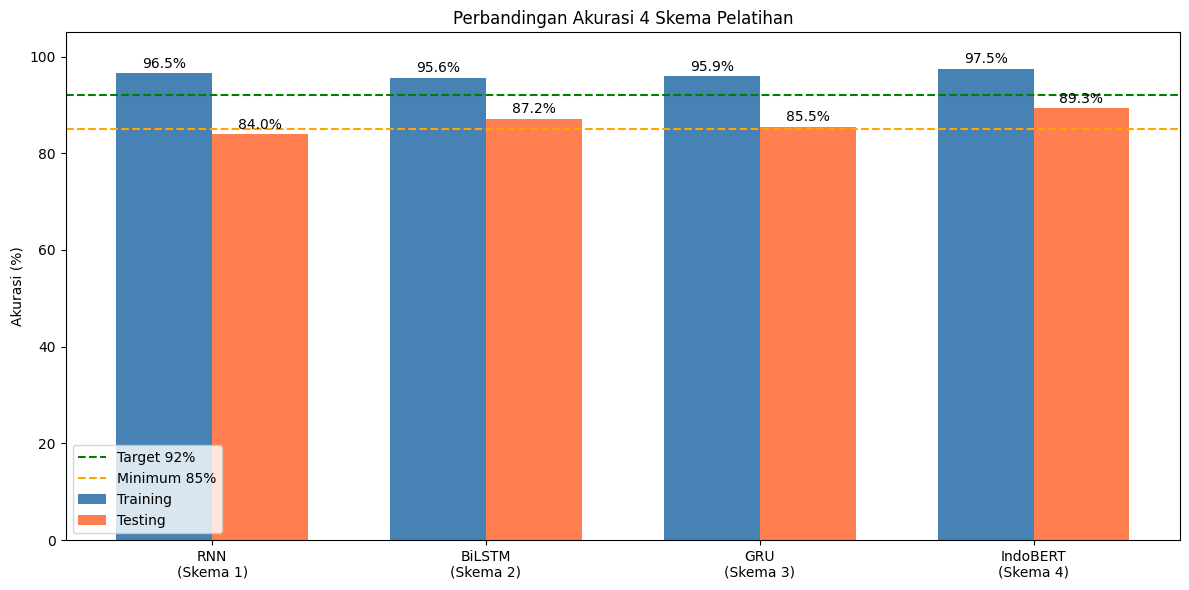

In [17]:
hasil = pd.DataFrame({
    'Skema'          : ['Skema 1 — RNN', 'Skema 2 — BiLSTM', 'Skema 3 — GRU', 'Skema 4 — IndoBERT'],
    'Algoritma'      : ['SimpleRNN', 'BiLSTM','GRU', 'IndoBERT'],
    'Fitur'          : ['Embedding Layer', 'FastText','FastText', 'BERT Tokenizer'],
    'Split'          : ['80/20', '80/20', '80/20','80/20'],
    'Akurasi Train %': [
        round(acc1_train*100, 2),
        round(acc2_train*100, 2),
        round(acc3_train*100, 2),
        round(tr_acc*100, 2)
    ],
    'Akurasi Test %' : [
        round(acc1_test*100, 2),
        round(acc2_test*100, 2),
        round(acc3_test*100, 2),
        round(final_acc*100, 2)
    ]
})

print(hasil.to_string(index=False))

# Visualisasi perbandingan
x = np.arange(4)
width = 0.35
fig, ax = plt.subplots(figsize=(12, 6)) # Adjusted figure size for better readability
bars1 = ax.bar(x - width/2, hasil['Akurasi Train %'], width, label='Training', color='steelblue')
bars2 = ax.bar(x + width/2, hasil['Akurasi Test %'],  width, label='Testing',  color='coral')
ax.axhline(y=92, color='green', linestyle='--', linewidth=1.5, label='Target 92%')
ax.axhline(y=85, color='orange', linestyle='--', linewidth=1.5, label='Minimum 85%')
ax.set_xticks(x)
ax.set_xticklabels(['RNN\n(Skema 1)', 'BiLSTM\n(Skema 2)','GRU\n(Skema 3)', 'IndoBERT\n(Skema 4)'])
ax.set_ylabel('Akurasi (%)')
ax.set_title('Perbandingan Akurasi 4 Skema Pelatihan')
ax.legend()
ax.set_ylim(0, 105)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('perbandingan_skema.png', dpi=150)
plt.show()

hasil.to_csv('hasil_perbandingan.csv', index=False)

---
## 🔮 5. Inference — Prediksi Kelas Kategorikal
### Input teks baru → Output: Negatif / Netral / Positif

In [10]:
def predict_rnn(teks):
    teks_bersih = preprocess(teks)
    seq = tokenizer_rnn.texts_to_sequences([teks_bersih])
    pad = pad_sequences(seq, maxlen=MAX_LEN)
    pred = model_rnn.predict(pad, verbose=0)
    kelas_id = np.argmax(pred, axis=1)[0]
    kelas = le.classes_[kelas_id]
    confidence = pred[0][kelas_id] * 100
    return kelas, confidence

contoh_teks = [
    'Aplikasinya sangat bagus dan mudah digunakan, pembelian tiket jadi gampang!',
    'Biasa saja sih, tidak ada yang spesial dari aplikasi ini',
    'Aplikasi sering error dan tiket tidak muncul setelah bayar, sangat mengecewakan!'
]

print('=== INFERENCE SKEMA 1 — RNN ===')
for teks in contoh_teks:
    kelas, conf = predict_rnn(teks)
    print(f'Input   : {teks}')
    print(f'Prediksi: {kelas} (confidence: {conf:.1f}%)')
    print('-' * 60)

=== INFERENCE SKEMA 1 — RNN ===
Input   : Aplikasinya sangat bagus dan mudah digunakan, pembelian tiket jadi gampang!
Prediksi: Positif (confidence: 99.8%)
------------------------------------------------------------
Input   : Biasa saja sih, tidak ada yang spesial dari aplikasi ini
Prediksi: Netral (confidence: 61.8%)
------------------------------------------------------------
Input   : Aplikasi sering error dan tiket tidak muncul setelah bayar, sangat mengecewakan!
Prediksi: Negatif (confidence: 99.8%)
------------------------------------------------------------


In [11]:
def predict_bilstm(teks):
    teks_bersih = preprocess(teks)
    seq = tokenizer_bilstm.texts_to_sequences([teks_bersih])
    pad = pad_sequences(seq, maxlen=MAX_LEN2)
    pred = model_bilstm.predict(pad, verbose=0)
    kelas_id = np.argmax(pred, axis=1)[0]
    kelas = le2.classes_[kelas_id]
    confidence = pred[0][kelas_id] * 100
    return kelas, confidence

print('=== INFERENCE SKEMA 2 — BiLSTM ===')
for teks in contoh_teks:
    kelas, conf = predict_bilstm(teks)
    print(f'Input   : {teks}')
    print(f'Prediksi: {kelas} (confidence: {conf:.1f}%)')
    print('-' * 60)

=== INFERENCE SKEMA 2 — BiLSTM ===
Input   : Aplikasinya sangat bagus dan mudah digunakan, pembelian tiket jadi gampang!
Prediksi: Positif (confidence: 100.0%)
------------------------------------------------------------
Input   : Biasa saja sih, tidak ada yang spesial dari aplikasi ini
Prediksi: Positif (confidence: 96.9%)
------------------------------------------------------------
Input   : Aplikasi sering error dan tiket tidak muncul setelah bayar, sangat mengecewakan!
Prediksi: Negatif (confidence: 99.6%)
------------------------------------------------------------


In [13]:
def predict_gru(teks):
    teks_bersih = preprocess(teks)
    seq = tokenizer_gru.texts_to_sequences([teks_bersih])
    pad = pad_sequences(seq, maxlen=MAX_LEN2)
    pred = model_gru.predict(pad, verbose=0)
    kelas_id = np.argmax(pred, axis=1)[0]
    kelas = le2.classes_[kelas_id]
    confidence = pred[0][kelas_id] * 100
    return kelas, confidence

print('=== INFERENCE SKEMA 3 — GRU ===')
for teks in contoh_teks:
    kelas, conf = predict_bilstm(teks)
    print(f'Input   : {teks}')
    print(f'Prediksi: {kelas} (confidence: {conf:.1f}%)')
    print('-' * 60)

=== INFERENCE SKEMA 3 — GRU ===
Input   : Aplikasinya sangat bagus dan mudah digunakan, pembelian tiket jadi gampang!
Prediksi: Positif (confidence: 100.0%)
------------------------------------------------------------
Input   : Biasa saja sih, tidak ada yang spesial dari aplikasi ini
Prediksi: Positif (confidence: 96.9%)
------------------------------------------------------------
Input   : Aplikasi sering error dan tiket tidak muncul setelah bayar, sangat mengecewakan!
Prediksi: Negatif (confidence: 99.6%)
------------------------------------------------------------


In [14]:
# ==================================================
# INFERENCE INTERAKTIF — Masukkan teks sendiri
# ==================================================
print('=== INFERENCE INTERAKTIF ===')
teks_input = input('Masukkan ulasan KAI Access: ')

k1, c1 = predict_rnn(teks_input)
k2, c2 = predict_bilstm(teks_input)
k3, c3 = predict_gru(teks_input)

print(f'\nHasil Prediksi untuk: "{teks_input}"')
print(f'  Skema 1 (RNN)      : {k1} ({c1:.1f}%)')
print(f'  Skema 2 (BiLSTM)   : {k2} ({c2:.1f}%)')
print(f'  Skema 3 (GRU) : {k3} ({c3:.1f}%)')

=== INFERENCE INTERAKTIF ===
Masukkan ulasan KAI Access: jelek

Hasil Prediksi untuk: "jelek"
  Skema 1 (RNN)      : Negatif (81.8%)
  Skema 2 (BiLSTM)   : Negatif (87.4%)
  Skema 3 (GRU) : Negatif (69.1%)


---
## 💾 6. Simpan Model

In [16]:
import pickle

model_rnn.save('model_rnn_kai.h5')
model_bilstm.save('model_bilstm_kai.h5')

with open('tokenizer_rnn.pkl', 'wb') as f:
    pickle.dump(tokenizer_rnn, f)
with open('tokenizer_bilstm.pkl', 'wb') as f:
    pickle.dump(tokenizer_bilstm, f)
with open('tokenizer_gru.pkl', 'wb') as f:
    pickle.dump(tokenizer_gru, f)
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print('Semua model berhasil disimpan!')

Semua model berhasil disimpan!


In [21]:
!pip freeze > requirements.txt

!cat requirements.txt

absl-py==1.4.0
accelerate==1.13.0
access==1.1.10.post3
affine==2.4.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.2
aiohttp==3.13.5
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.18.4
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.13.0
anywidget==0.9.21
apsw==3.53.1.0
apswutils==0.1.2
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.0
astropy-iers-data==0.2026.5.18.1.11.28
asttokens==3.0.1
astunparse==1.6.3
atpublic==5.1
attrs==26.1.0
audioread==3.1.0
Authlib==1.7.2
autograd==1.8.0
babel==2.18.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.40.0
bigquery-magics==0.14.0
bleach==6.3.0
blinker==1.9.0
blis==1.3.3
blobfile==3.2.0
blosc2==4.3.3
bokeh==3.8.2
Bottleneck==1.4.2
bqplot==0.12.47
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cachetools==6.2.6
catalogue==2.0.10
cer